# Prueba de Concepto (PoC) V2.0 - TFM Fases 1 y 2

Este notebook implementa las dos primeras fases de la arquitectura híbrida GNN-HVA para la caracterización de fases topológicas, utilizando el Modelo de Ising en Campo Transversal (TFIM) 1D como sistema de prueba.

**Correcciones respecto a V1:**
- Función de costo basada en energía (StatevectorEstimator), no fidelidad global
- Factor `2*theta` en puertas RZZ/RX para correspondencia física correcta
- Diagonalización exacta densa (`np.linalg.eigh`) en lugar de `eigsh`
- Observables promediados sobre todos los sitios
- Almacenamiento de energías, gaps y persistencia de datos

## Celda 1: Importaciones y Configuración Inicial

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from qiskit.quantum_info import SparsePauliOp, Statevector, state_fidelity
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.primitives import StatevectorEstimator

# Configuración del modelo
N = 6
J = 1.0
h_values = np.linspace(0.0, 2.0, 21)
p_layers = 2

print(f"TFIM 1D: N={N}, J={J}, p={p_layers}, h ∈ [{h_values[0]}, {h_values[-1]}]")

TFIM 1D: N=6, J=1.0, p=2, h ∈ [0.0, 2.0]


## Celda 2: Construcción del Hamiltoniano y Observables

In [14]:
def build_tfim_hamiltonian(N, J, h):
    """H = -J Σ ZᵢZᵢ₊₁ - h Σ Xᵢ"""
    terms = []
    for i in range(N - 1):
        terms.append(("ZZ", [i, i + 1], -J))
    for i in range(N):
        terms.append(("X", [i], -h))
    return SparsePauliOp.from_sparse_list(terms, num_qubits=N)

# Observables locales por sitio
ops_X = [SparsePauliOp.from_sparse_list([("X", [i], 1.0)], num_qubits=N) for i in range(N)]
ops_ZZ = [SparsePauliOp.from_sparse_list([("ZZ", [i, i+1], 1.0)], num_qubits=N) for i in range(N - 1)]

print(f"Observables: {N} sitios ⟨Xᵢ⟩, {N-1} enlaces ⟨ZᵢZᵢ₊₁⟩")

Observables: 6 sitios ⟨Xᵢ⟩, 5 enlaces ⟨ZᵢZᵢ₊₁⟩


## Celda 3: FASE 1 — Diagonalización Exacta y Ground Truth

Fase 1: Diagonalización exacta...


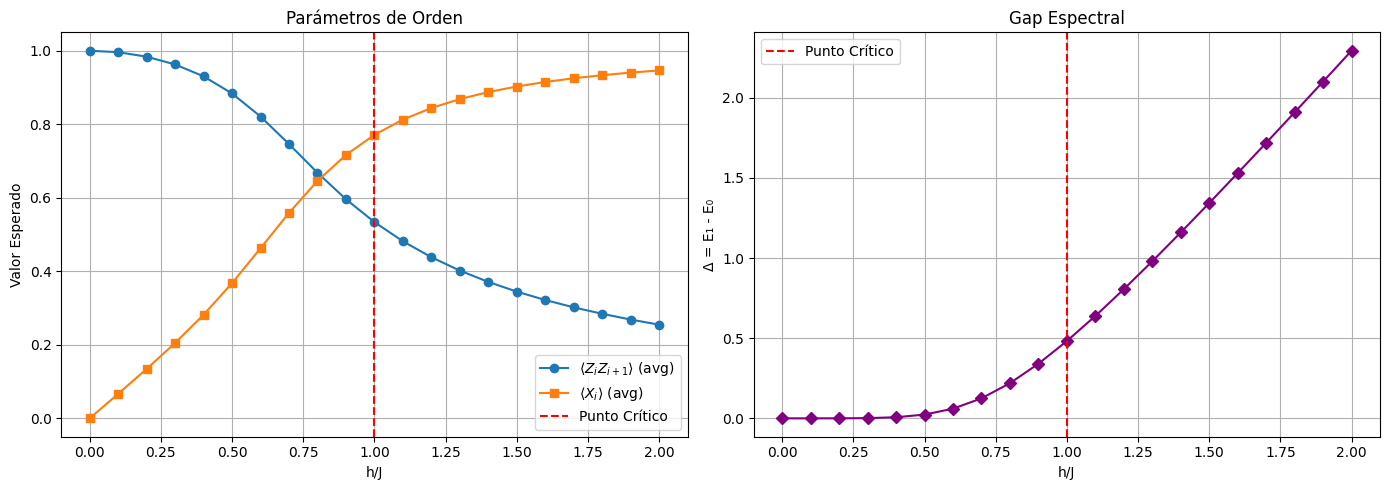

Fase 1 completada. Gap mínimo: 0.000000


In [15]:
exact_data = []

print("Fase 1: Diagonalización exacta...")
for h in h_values:
    H = build_tfim_hamiltonian(N, J, h)
    evals, evecs = np.linalg.eigh(H.to_matrix())
    psi_gs = np.ascontiguousarray(evecs[:, 0])
    sv = Statevector(psi_gs)

    mag_x = np.mean([sv.expectation_value(op).real for op in ops_X])
    corr_zz = np.mean([sv.expectation_value(op).real for op in ops_ZZ])

    exact_data.append({
        "h": h, "ground_energy": evals[0], "gap": evals[1] - evals[0],
        "ground_state": psi_gs, "mag_x": mag_x, "corr_zz": corr_zz,
    })

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(h_values, [d["corr_zz"] for d in exact_data], 'o-', label=r'$\langle Z_i Z_{i+1} \rangle$ (avg)')
ax1.plot(h_values, [d["mag_x"] for d in exact_data], 's-', label=r'$\langle X_i \rangle$ (avg)')
ax1.axvline(x=1.0, color='red', linestyle='--', label='Punto Crítico')
ax1.set_xlabel('h/J'); ax1.set_ylabel('Valor Esperado')
ax1.set_title('Parámetros de Orden'); ax1.legend(); ax1.grid(True)

ax2.plot(h_values, [d["gap"] for d in exact_data], 'D-', color='purple')
ax2.axvline(x=1.0, color='red', linestyle='--', label='Punto Crítico')
ax2.set_xlabel('h/J'); ax2.set_ylabel('Δ = E₁ - E₀')
ax2.set_title('Gap Espectral'); ax2.legend(); ax2.grid(True)

plt.tight_layout(); plt.show()
print(f"Fase 1 completada. Gap mínimo: {min(d['gap'] for d in exact_data):.6f}")

## Celda 4: FASE 2 (Parte A) — Ansatz HVA con factor 2θ correcto

HVA: 4 parámetros, profundidad p=2


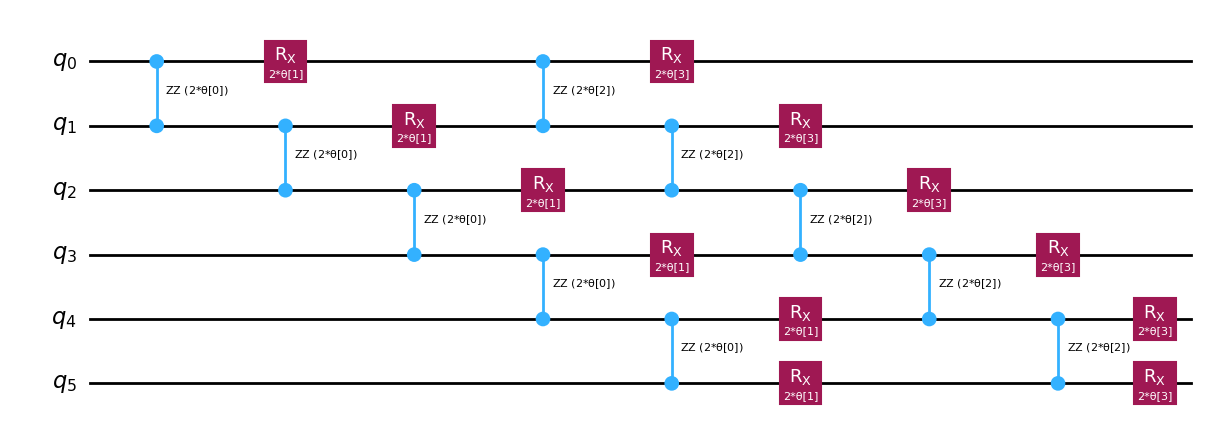

In [16]:
def create_hva_circuit(N, p):
    """HVA: e^{-iθ_x H_X} · e^{-iθ_zz H_ZZ} por capa sobre |+⟩^N. Factor 2θ para RZZ/RX."""
    qc = QuantumCircuit(N)
    # Estado inicial |+⟩^N: ground state paramagnético (h → ∞)
    qc.h(range(N))
    theta = ParameterVector('θ', 2 * p)

    for layer in range(p):
        for i in range(N - 1):
            qc.rzz(2 * theta[layer * 2], i, i + 1)
        for i in range(N):
            qc.rx(2 * theta[layer * 2 + 1], i)

    return qc, theta

hva_qc, theta_params = create_hva_circuit(N, p_layers)
print(f"HVA: {hva_qc.num_parameters} parámetros, profundidad p={p_layers}")
hva_qc.draw('mpl')

## Celda 5: FASE 2 (Parte B) — VQE con Warm Start y costo energético

Fase 2: VQE warm-start sweep (p=2)...
  ⚠️  h=0.10: fidelidad=0.4962, ΔE=2.00e-02, converged=True
  ⚠️  h=0.20: fidelidad=0.4849, ΔE=8.03e-02, converged=True
  ⚠️  h=0.30: fidelidad=0.4657, ΔE=1.82e-01, converged=True
  ⚠️  h=0.40: fidelidad=0.4373, ΔE=3.28e-01, converged=True
  ⚠️  h=0.50: fidelidad=0.3982, ΔE=5.22e-01, converged=True
  ⚠️  h=0.60: fidelidad=0.3485, ΔE=7.71e-01, converged=True
  ⚠️  h=0.70: fidelidad=0.2931, ΔE=1.08e+00, converged=True
  ⚠️  h=0.80: fidelidad=0.2400, ΔE=1.44e+00, converged=True
  ⚠️  h=0.90: fidelidad=0.1953, ΔE=1.85e+00, converged=True
  ⚠️  h=1.00: fidelidad=0.1604, ΔE=2.30e+00, converged=True
  ⚠️  h=1.10: fidelidad=0.1341, ΔE=2.77e+00, converged=True
  ⚠️  h=1.20: fidelidad=0.1144, ΔE=3.27e+00, converged=True
  ⚠️  h=1.30: fidelidad=0.0994, ΔE=3.78e+00, converged=True
  ⚠️  h=1.40: fidelidad=0.0878, ΔE=4.31e+00, converged=True
  ⚠️  h=1.50: fidelidad=0.0787, ΔE=4.85e+00, converged=True
  ⚠️  h=1.60: fidelidad=0.0714, ΔE=5.39e+00, converged=True
  

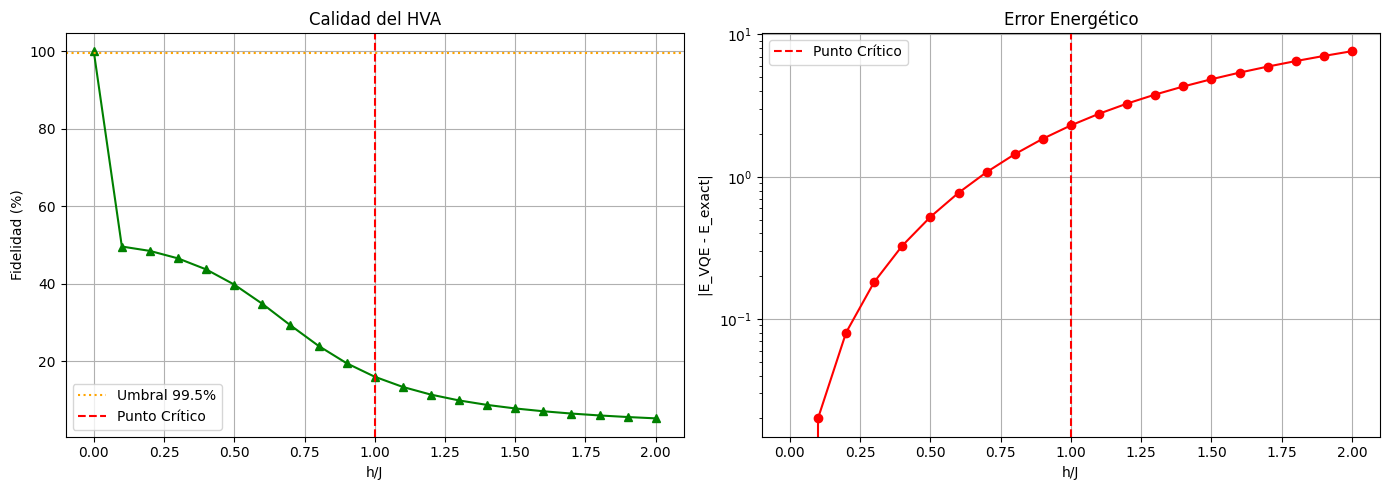


--- RESULTADOS FASE 2 ---
Fidelidad: promedio=25.44%, mínima=5.31%
Error energético máximo: 7.63e+00


In [17]:
estimator = StatevectorEstimator()
vqe_results = []

# Warm start: θ=0 → |+⟩^N (estado paramagnético, ground state a h→∞)
current_guess = np.zeros(hva_qc.num_parameters)

print(f"Fase 2: VQE warm-start sweep (p={p_layers})...")
for idx, h in enumerate(h_values):
    H = build_tfim_hamiltonian(N, J, h)

    def cost(params):
        bound = hva_qc.assign_parameters(params)
        return estimator.run([(bound, H)]).result()[0].data.evs

    res = minimize(cost, current_guess, method='L-BFGS-B',
                   options={'maxiter': 500, 'ftol': 1e-12})

    # Validación: fidelidad y error energético
    bound_qc = hva_qc.assign_parameters(res.x)
    sv_ansatz = Statevector(bound_qc)
    fid = state_fidelity(sv_ansatz, Statevector(exact_data[idx]["ground_state"]))
    e_exact = exact_data[idx]["ground_energy"]
    e_error = abs(res.fun - e_exact)

    if not res.success or fid < 0.995:
        print(f"  ⚠️  h={h:.2f}: fidelidad={fid:.4f}, ΔE={e_error:.2e}, converged={res.success}")

    vqe_results.append({
        "h": h, "theta_opt": res.x.copy(), "energy": res.fun,
        "energy_error": e_error, "fidelity": fid, "n_iters": res.nit,
    })
    current_guess = res.x  # warm start

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(h_values, [r["fidelity"] * 100 for r in vqe_results], 'g^-')
ax1.axhline(y=99.5, color='orange', linestyle=':', label='Umbral 99.5%')
ax1.axvline(x=1.0, color='red', linestyle='--', label='Punto Crítico')
ax1.set_xlabel('h/J'); ax1.set_ylabel('Fidelidad (%)')
ax1.set_title('Calidad del HVA'); ax1.legend(); ax1.grid(True)

ax2.semilogy(h_values, [r["energy_error"] for r in vqe_results], 'ro-')
ax2.axvline(x=1.0, color='red', linestyle='--', label='Punto Crítico')
ax2.set_xlabel('h/J'); ax2.set_ylabel('|E_VQE - E_exact|')
ax2.set_title('Error Energético'); ax2.legend(); ax2.grid(True)

plt.tight_layout(); plt.show()

fids = [r["fidelity"] for r in vqe_results]
print(f"\n--- RESULTADOS FASE 2 ---")
print(f"Fidelidad: promedio={np.mean(fids)*100:.2f}%, mínima={np.min(fids)*100:.2f}%")
print(f"Error energético máximo: {max(r['energy_error'] for r in vqe_results):.2e}")

## Celda 6: Persistencia de Datos para Fase 3

In [18]:
np.savez("phase1_phase2_tfim_N6_p2.npz",
    h_values=h_values, J=J, n_qubits=N, p_layers=p_layers,
    ground_energies=np.array([d["ground_energy"] for d in exact_data]),
    gaps=np.array([d["gap"] for d in exact_data]),
    mag_x=np.array([d["mag_x"] for d in exact_data]),
    corr_zz=np.array([d["corr_zz"] for d in exact_data]),
    theta_opt=np.array([r["theta_opt"] for r in vqe_results]),
    vqe_energies=np.array([r["energy"] for r in vqe_results]),
    fidelities=np.array([r["fidelity"] for r in vqe_results]),
)
print("Dataset guardado: phase1_phase2_tfim_N6_p2.npz")

Dataset guardado: phase1_phase2_tfim_N6_p2.npz
